# Reddit Mental Health Risk Classification
## SNS 텍스트 기반 정신건강 위험군 분류 — Naïve Bayes 직접 구현

Reddit의 r/depression, r/SuicideWatch(위험군)와 r/happy(비위험군) 게시물을 분류하는 Naïve Bayes

## 1. 데이터 로드 및 탐색

In [1]:
import pandas as pd
import numpy as np
import re
import matplotlib.pyplot as plt

df = pd.read_csv('/Users/jungyoon/Downloads/reddit_depression_dataset.csv')
print(df.shape)
print(df.head())
print(df['subreddit'].value_counts())
print(df.isnull().sum())

/var/folders/44/q6k9m2p14bnfv6j1p_y37bfh0000gn/T/ipykernel_35695/1092481582.py:6: DtypeWarning: Columns (0) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv('/Users/jungyoon/Downloads/reddit_depression_dataset.csv')


(2470778, 8)
  Unnamed: 0     subreddit                                              title  \
0      47951  DeepThoughts                             Deep thoughts underdog   
1      47952  DeepThoughts  I like this sub, there's only two posts yet I ...   
2      47957  DeepThoughts                                           Rebirth!   
3      47959  DeepThoughts  "I want to be like water. I want to slip throu...   
4      47960  DeepThoughts                                          Who am I?   

                                                body  upvotes   created_utc  \
0  Only when we start considering ourselves, the ...      4.0  1.405309e+09   
1  Anyway: Human Morality is a joke so long as th...      4.0  1.410568e+09   
2  Hello. \nI am the new guy in charge here (Besi...      6.0  1.416458e+09   
3                                                NaN     25.0  1.416512e+09   
4  You could take any one cell in my body and kil...      5.0  1.416516e+09   

   num_comments  label  


## 2. 데이터 전처리 및 클래스 균형 맞추기

- depression, SuicideWatch → 위험군 (1)
- happy → 비위험군 (0)
- 클래스 불균형 해결: 위험군 언더샘플링 → 1:1 균형

In [2]:
df_filtered = df[df['subreddit'].isin(['depression', 'SuicideWatch', 'happy'])].copy()
df_filtered['label_binary'] = df_filtered['subreddit'].apply(
    lambda x: 1 if x in ['depression', 'SuicideWatch'] else 0
)

df_pos = df_filtered[df_filtered['label_binary'] == 1].sample(24609, random_state=42)
df_neg = df_filtered[df_filtered['label_binary'] == 0]

df_balanced = pd.concat([df_pos, df_neg]).reset_index(drop=True)
print(df_balanced['label_binary'].value_counts())
print(df_balanced.shape)

label_binary
1    24609
0    24609
Name: count, dtype: int64
(49218, 9)


## 3. 클래스 분포 시각화

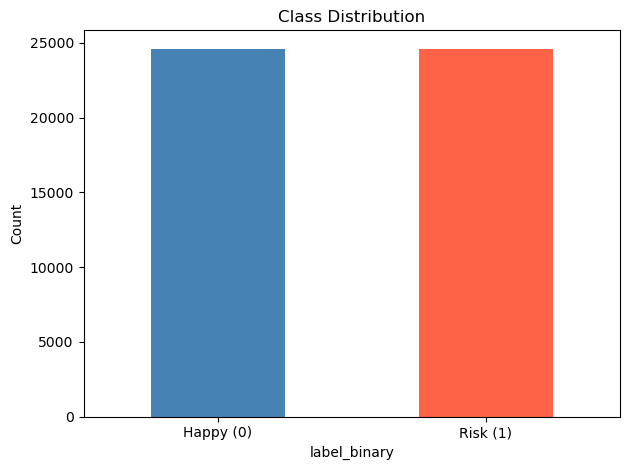

In [3]:
df_balanced['label_binary'].value_counts().plot(kind='bar', color=['steelblue', 'tomato'])
plt.title('Class Distribution')
plt.xticks([0, 1], ['Happy (0)', 'Risk (1)'], rotation=0)
plt.ylabel('Count')
plt.tight_layout()
plt.savefig('class_dist.png', dpi=150)
plt.show()

## 4. 텍스트 전처리

- 소문자 변환
- 특수문자 제거
- 결측치 제거

In [4]:
# 결측치 제거
df_balanced = df_balanced.dropna(subset=['title'])
print(df_balanced.shape)

# 텍스트 전처리 함수
def preprocess(text):
    text = text.lower()                          # 소문자 변환
    text = re.sub(r'[^a-z\s]', '', text)        # 특수문자 제거
    text = re.sub(r'\s+', ' ', text).strip()    # 공백 정리
    return text

df_balanced['title_clean'] = df_balanced['title'].apply(preprocess)
print(df_balanced[['title', 'title_clean']].head())

(49218, 9)
                                               title  \
0  I tell girls I love them but none love me back...   
1                  I will not hesitate to gut myself   
2                          Been in a rut for so long   
3  Just turned 26. Realized I've had depression f...   
4  Today I thought about cutting myself for the f...   

                                         title_clean  
0     i tell girls i love them but none love me back  
1                  i will not hesitate to gut myself  
2                          been in a rut for so long  
3  just turned realized ive had depression for ov...  
4  today i thought about cutting myself for the f...  


## 5. Bag of Words 변환

텍스트를 Bag of Words 행렬로 변환합니다.
- binary=True: 단어 등장 여부 0/1 (수업 코드와 동일한 구조)

In [5]:
from sklearn.feature_extraction.text import CountVectorizer

cv = CountVectorizer(max_features=1000, stop_words='english', binary=True)
X_bow = cv.fit_transform(df_balanced['title_clean']).toarray()
Y = df_balanced['label_binary'].values

print(f'X_bow shape: {X_bow.shape}')  # (49218, 1000)
print(f'Y shape: {Y.shape}')          # (49218,)

X_bow shape: (49218, 1000)
Y shape: (49218,)


## 6. Naïve Bayes 직접 구현

수업에서 배운 원리를 직접 구현합니다.

**핵심 수식:**
```
P(Y=y | X=x) ∝ P(Y=y) × ∏ P(Xj=xj | Y=y)
```

**MAP 추정 (Smoothing 적용):**
```
P(Xj|Y=y) = (C(Xj, Y=y) + α - 1) / (C(Y=y) + α + β - 2)
```

In [ ]:
numDoc = len(X_bow)
numTesting = int(numDoc * 0.2)
numVoca = X_bow.shape[1]
alpha = 1.0   # Beta prior 파라미터
beta = 1.0    # Beta prior 파라미터
delta = 1e-12 # log(0) 방지

# Train/Test 분리
X_train_bow = X_bow[:numDoc-numTesting]
X_test_bow = X_bow[numDoc-numTesting:]
Y_train = Y[:numDoc-numTesting]
Y_test = Y[numDoc-numTesting:]

# 카운팅: C(Y=y)
cntY = np.zeros((2, 1))
cntY[0] = np.sum(Y_train == 0)  # 비위험군 개수
cntY[1] = np.sum(Y_train == 1)  # 위험군 개수

# 카운팅: C(Xj, Y=y)
cntXbyY = np.zeros((numVoca, 2))
for i in range(numVoca):
    cntXbyY[i, 0] = np.sum(X_train_bow[Y_train == 0, i] >= 1)
    cntXbyY[i, 1] = np.sum(X_train_bow[Y_train == 1, i] >= 1)

# 확률 계산: P(Xj|Y) with MAP 추정
probsXbyY = np.zeros((numVoca, 2))
for i in range(numVoca):
    for j in range(2):
        probsXbyY[i, j] = (cntXbyY[i, j] + alpha - 1) / float(cntY[j] + alpha + beta - 2 + delta)

# P(Y) 계산
probsY = np.zeros((2, 1))
probsY[0] = cntY[0] / float(cntY[0] + cntY[1])
probsY[1] = cntY[1] / float(cntY[0] + cntY[1])

# Log Probability 계산 및 예측
logProbs = np.zeros((numTesting, 2))
for i in range(numTesting):
    for k in range(2):
        logProbs[i, k] = np.log(probsY[k, 0] + delta)
        for j in range(numVoca):
            if X_test_bow[i, j] >= 1:
                logProbs[i, k] += np.log(probsXbyY[j, k] + delta)
            else:
                logProbs[i, k] += np.log(1 - probsXbyY[j, k] + delta)

estY = np.argmax(logProbs, axis=1)
accuracy = np.mean(estY == Y_test)
print(f'직접 구현 Naïve Bayes 정확도: {accuracy:.4f}')

/var/folders/44/q6k9m2p14bnfv6j1p_y37bfh0000gn/T/ipykernel_35695/3467222407.py:29: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  probsXbyY[i, j] = (cntXbyY[i, j] + alpha - 1) / float(cntY[j] + alpha + beta - 2 + delta)
/var/folders/44/q6k9m2p14bnfv6j1p_y37bfh0000gn/T/ipykernel_35695/3467222407.py:33: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  probsY[0] = cntY[0] / float(cntY[0] + cntY[1])
/var/folders/44/q6k9m2p14bnfv6j1p_y37bfh0000gn/T/ipykernel_35695/3467222407.py:34: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before

## Step 7. sklearn 검증

직접 구현 결과와 sklearn BernoulliNB 결과를 비교합니다.

In [ ]:
from sklearn.naive_bayes import BernoulliNB
from sklearn.metrics import classification_report

nb_sklearn = BernoulliNB()
nb_sklearn.fit(X_train_bow, Y_train)
y_pred_sklearn = nb_sklearn.predict(X_test_bow)

print(f'sklearn Naïve Bayes 정확도: {nb_sklearn.score(X_test_bow, Y_test):.4f}')
print(classification_report(Y_test, y_pred_sklearn))

## Step 8. 위험 단어 분석

위험군에서 많이 나오는 단어를 분석합니다.

In [ ]:
words = cv.get_feature_names_out()
log_prob_diff = probsXbyY[:, 1] - probsXbyY[:, 0]
top_danger_idx = log_prob_diff.argsort()[-20:][::-1]

print('위험군에서 많이 나오는 단어들:')
for idx in top_danger_idx:
    print(f'{words[idx]}: {log_prob_diff[idx]:.4f}')

## Step 9. 시각화

In [ ]:
# 위험 단어 바차트
plt.figure(figsize=(10, 6))
plt.barh(words[top_danger_idx], log_prob_diff[top_danger_idx], color='tomato')
plt.title('Top 20 Risk Words')
plt.xlabel('Probability Difference (Risk - Safe)')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.savefig('top_words.png', dpi=150)
plt.show()

In [ ]:
# 워드클라우드
from wordcloud import WordCloud

danger_words = {words[idx]: float(log_prob_diff[idx]) for idx in top_danger_idx}
wc = WordCloud(width=800, height=400, background_color='white')
wc.generate_from_frequencies(danger_words)
plt.figure(figsize=(10, 5))
plt.imshow(wc, interpolation='bilinear')
plt.axis('off')
plt.title('위험군에서 많이 나오는 단어들')
plt.savefig('danger_words.png', dpi=150, bbox_inches='tight')
plt.show()

In [ ]:
# Confusion Matrix
from sklearn.metrics import ConfusionMatrixDisplay, confusion_matrix

cm = confusion_matrix(Y_test, estY)
disp = ConfusionMatrixDisplay(cm, display_labels=['Happy', 'Risk'])
disp.plot(cmap='Blues')
plt.title('Confusion Matrix')
plt.savefig('confusion_matrix.png', dpi=150)
plt.show()